# sPCA alpha sweep: program stability across alpha (fixed n_components=78)

For each alpha in the sweep, the fixed-n_components (78) fit produced by `01_spca_alpha_sweep.py`
has no canonical ordering relative to the alpha=1.0 reference fit (sPCA components can permute
freely across independent fits). This notebook pairs each reference program with its best
available match at each alpha -- the fitted component with the highest cosine similarity to it
(computed on per-program z-scored loadings) -- so that "component 5" at alpha=0.8 can be
identified with the reference program it most resembles, then visualizes the result.

Matching is unconstrained: two reference programs that share genes may both pick the same fitted
component as their best available match.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['text.usetex']  = False

# Repo-relative paths (inputs: imports_stable/, outputs: analysis_outs/)
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"
REFERENCE_COMPONENTS = (
    f"{IMPORTS_DIR}/SIG13/analysis_outs/spca/degs_zscore_allLigands/"
    "zscore_degs_allLigands_0.1_alpha1.0_sPCA_components.csv"
)
CLEAN_COMPONENTS = (
    f"{IMPORTS_DIR}/SIG13/analysis_outs/spca/"
    "lm_fit_zscore_degs_allLigands_0.1_alpha1.0_sPCA_clean.csv"
)
SWEEP_DIR = f"{IMPORTS_DIR}/SIG13/analysis_outs/spca_stability/alpha_sweep"
SWEEP_OUT_DIR = f"{OUTS_DIR}/spca_stability/alpha_sweep"
os.makedirs(SWEEP_OUT_DIR, exist_ok=True)
PLOT_DIR = f"{OUTS_DIR}/spca_stability/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

ALPHA_VALUES = [round(a, 1) for a in np.arange(0.1, 3.01, 0.1)]
COLLAPSE_NORM_TOL = 1e-8

In [2]:
def load_components(path):
    """Load a components CSV (gene, 0, 1, ..., n-1) sorted by gene for stable alignment."""
    df = pd.read_csv(path).sort_values("gene").reset_index(drop=True)
    genes = df["gene"].values
    mat = df.drop(columns="gene").to_numpy(dtype=np.float64).T  # components x genes
    return genes, mat


def match_to_reference(ref_genes, ref_mat, genes, mat):
    """Best available (unconstrained) match of each reference program to a query fit.

    Each reference program is paired with whichever query component it is most similar to;
    several reference programs may share the same best-matching component.
    """
    if not np.array_equal(ref_genes, genes):
        common = np.intersect1d(ref_genes, genes)
        if len(common) == 0:
            raise ValueError("No overlapping genes between reference and query components.")
        ref_idx = {g: i for i, g in enumerate(ref_genes)}
        q_idx = {g: i for i, g in enumerate(genes)}
        ref_mat = ref_mat[:, [ref_idx[g] for g in common]]
        mat = mat[:, [q_idx[g] for g in common]]

    ref_norm = np.linalg.norm(ref_mat, axis=1)
    q_norm = np.linalg.norm(mat, axis=1)

    scaler = StandardScaler()
    ref_mat = scaler.fit_transform(ref_mat.T).T
    mat = scaler.fit_transform(mat.T).T

    sim = cosine_similarity(ref_mat, mat)
    ref_ind = np.arange(sim.shape[0])

    best_available_component = np.argmax(sim, axis=1)
    best_available_similarity = sim[ref_ind, best_available_component]

    return pd.DataFrame(
        {
            "ref_component": ref_ind,
            "ref_component_collapsed": ref_norm < COLLAPSE_NORM_TOL,
            "best_available_component": best_available_component,
            "best_available_similarity": best_available_similarity,
            "best_available_component_collapsed": q_norm[best_available_component] < COLLAPSE_NORM_TOL,
        }
    )

In [3]:
ref_genes, ref_mat = load_components(REFERENCE_COMPONENTS)

records = []
for alpha in ALPHA_VALUES:
    if alpha == 1.0:
        path = REFERENCE_COMPONENTS
    else:
        path = f"{SWEEP_DIR}/zscore_degs_allLigands_0.1_alpha{alpha}_sPCA_components.csv"

    try:
        genes, mat = load_components(path)
    except FileNotFoundError:
        print(f"[skip] alpha={alpha}: {path} not found (run 01_spca_alpha_sweep.py first)")
        continue

    matched = match_to_reference(ref_genes, ref_mat, genes, mat)
    matched.insert(0, "alpha", alpha)
    records.append(matched)
    print(
        f"alpha={alpha}: median best available cosine similarity = "
        f"{matched['best_available_similarity'].median():.3f}"
    )

df = pd.concat(records, ignore_index=True)
df.to_csv(f"{SWEEP_OUT_DIR}/matched_similarity_long.csv", index=False)
print(f"\nWrote {len(df)} rows to {SWEEP_OUT_DIR}/matched_similarity_long.csv")
df.head()

alpha=0.1: median best available cosine similarity = 0.672
alpha=0.2: median best available cosine similarity = 0.751
alpha=0.3: median best available cosine similarity = 0.805


alpha=0.4: median best available cosine similarity = 0.804
alpha=0.5: median best available cosine similarity = 0.834
alpha=0.6: median best available cosine similarity = 0.854


alpha=0.7: median best available cosine similarity = 0.867
alpha=0.8: median best available cosine similarity = 0.914
alpha=0.9: median best available cosine similarity = 0.950


alpha=1.0: median best available cosine similarity = 1.000
alpha=1.1: median best available cosine similarity = 0.947
alpha=1.2: median best available cosine similarity = 0.952
alpha=1.3: median best available cosine similarity = 0.920


alpha=1.4: median best available cosine similarity = 0.930
alpha=1.5: median best available cosine similarity = 0.875
alpha=1.6: median best available cosine similarity = 0.884
alpha=1.7: median best available cosine similarity = 0.872


alpha=1.8: median best available cosine similarity = 0.866
alpha=1.9: median best available cosine similarity = 0.848
alpha=2.0: median best available cosine similarity = 0.845
alpha=2.1: median best available cosine similarity = 0.825


alpha=2.2: median best available cosine similarity = 0.832
alpha=2.3: median best available cosine similarity = 0.840
alpha=2.4: median best available cosine similarity = 0.811
alpha=2.5: median best available cosine similarity = 0.839


alpha=2.6: median best available cosine similarity = 0.842
alpha=2.7: median best available cosine similarity = 0.831
alpha=2.8: median best available cosine similarity = 0.843
alpha=2.9: median best available cosine similarity = 0.842


alpha=3.0: median best available cosine similarity = 0.809

Wrote 2340 rows to /data1/rudenska/EYW/git_projects/SIG13/analysis_outs/spca_stability/alpha_sweep/matched_similarity_long.csv


,alpha,ref_component,ref_component_collapsed,best_available_component,best_available_similarity,best_available_component_collapsed
0,0.1,0,False,52,0.305039,False
1,0.1,1,False,74,0.717400,False
2,0.1,2,False,40,0.846401,False
3,0.1,3,False,76,0.519104,False
4,0.1,4,False,4,0.681842,False


In [4]:
n_collapsed = df[["alpha", "best_available_component_collapsed"]].groupby("alpha").sum()
print("Collapsed (near-zero-norm) best available components per alpha:")
n_collapsed[n_collapsed["best_available_component_collapsed"] > 0]

Collapsed (near-zero-norm) best available components per alpha:


,best_available_component_collapsed
alpha,


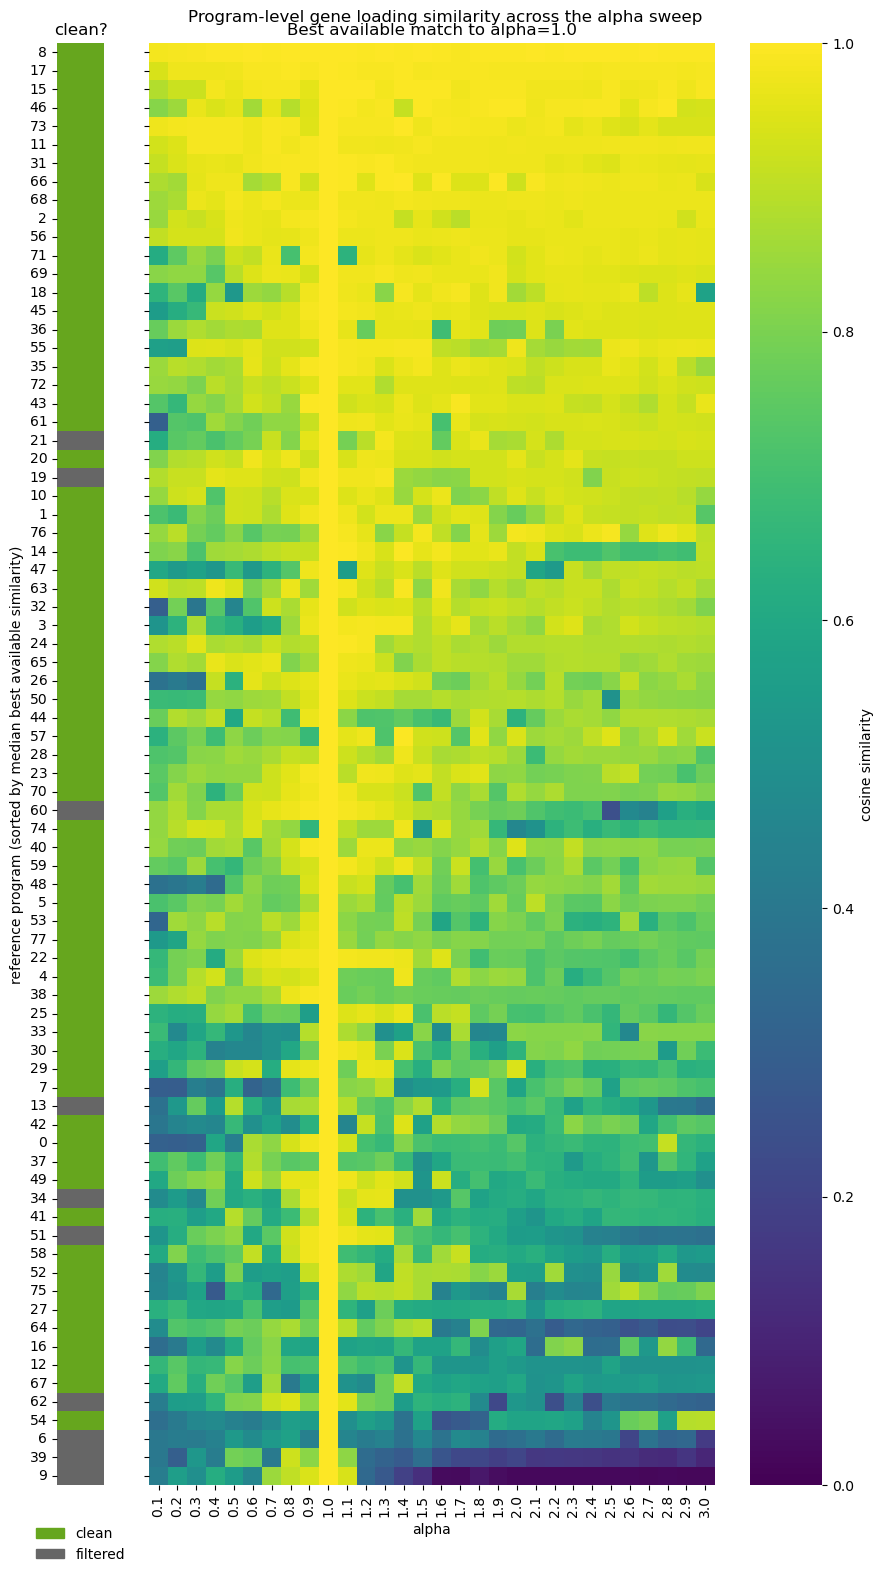

In [5]:
# Heatmap: reference program (row) x alpha (column), best available cosine similarity, with a
# side strip marking whether the alpha=1.0 program survived cleanup (present in
# lm_fit_zscore_degs_allLigands_0.1_alpha1.0_sPCA_clean.csv) or was filtered out
clean_component_ids = set(
    int(c.split("_")[1]) for c in pd.read_csv(CLEAN_COMPONENTS)["component"].unique()
)

pivot_best = df.pivot(index="ref_component", columns="alpha", values="best_available_similarity")

# order rows by median similarity across alphas so unstable programs are easy to spot
row_order = pivot_best.median(axis=1).sort_values(ascending=False).index
pivot_best = pivot_best.loc[row_order]
is_clean = pd.DataFrame(
    {"clean": [int(comp in clean_component_ids) for comp in row_order]}, index=row_order
)

fig, axes = plt.subplots(
    1, 2, figsize=(9, 16), sharey=True, gridspec_kw={"width_ratios": [1, 15]}
)
sns.heatmap(is_clean, cmap=["#666666", "#66a61e"], vmin=0, vmax=1, cbar=False, xticklabels=False, ax=axes[0])
axes[0].set_ylabel("reference program (sorted by median best available similarity)")
axes[0].set_title("clean?")
axes[0].legend(
    handles=[mpatches.Patch(color="#66a61e", label="clean"), mpatches.Patch(color="#666666", label="filtered")],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
)

sns.heatmap(pivot_best, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "cosine similarity"}, ax=axes[1])
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("")
axes[1].set_title("Best available match to alpha=1.0")

fig.suptitle("Program-level gene loading similarity across the alpha sweep")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/alpha_sweep_similarity_heatmap.pdf")
plt.show()

/tmp/ipykernel_1260593/847637747.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)


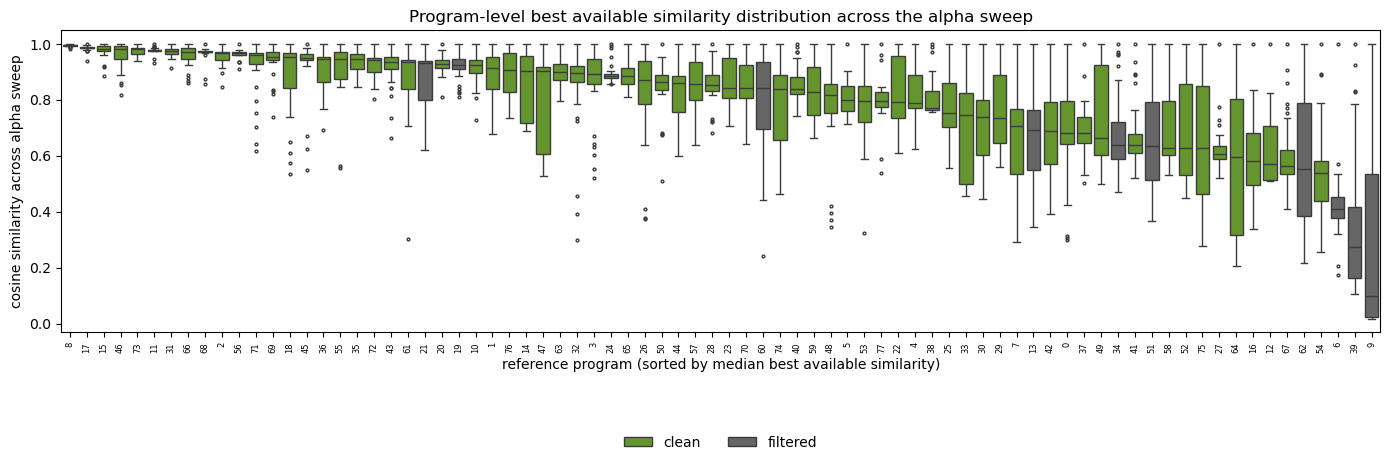

In [6]:
# Boxplots: per-program distribution of best available cosine similarity across the alpha sweep,
# colored by whether the program survived cleanup (clean) or was filtered out
df_plot = df.copy()
df_plot["status"] = df_plot["ref_component"].map(
    lambda c: "clean" if c in clean_component_ids else "filtered"
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df_plot,
    x="ref_component",
    y="best_available_similarity",
    order=row_order,
    hue="status",
    hue_order=["clean", "filtered"],
    palette={"clean": "#66a61e", "filtered": "#666666"},
    dodge=False,
    fliersize=2,
    ax=ax,
)
ax.set_xlabel("reference program (sorted by median best available similarity)")
ax.set_ylabel("cosine similarity across alpha sweep")
ax.set_title("Program-level best available similarity distribution across the alpha sweep")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/alpha_sweep_similarity_boxplot.pdf")
plt.show()

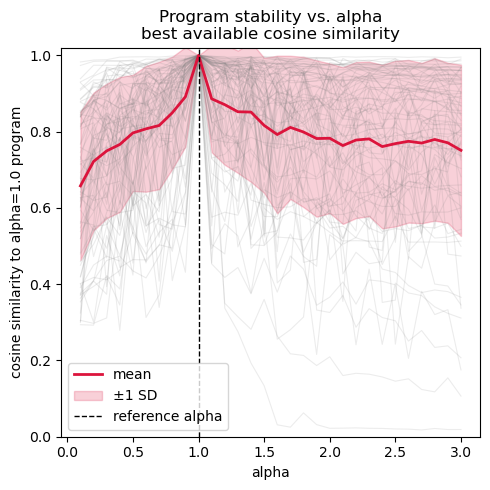

In [7]:
# Mean (+ per-program faint lines) best available similarity vs alpha
fig, ax = plt.subplots(figsize=(5, 5))
for ref_comp, sub in df.groupby("ref_component"):
    sub = sub.sort_values("alpha")
    ax.plot(sub["alpha"], sub["best_available_similarity"], color="grey", alpha=0.15, linewidth=0.8)

summary = df.groupby("alpha").agg(
    mean=("best_available_similarity", "mean"),
    std=("best_available_similarity", "std"),
)
ax.plot(summary.index, summary["mean"], color="crimson", linewidth=2, label="mean")
ax.fill_between(
    summary.index,
    summary["mean"] - summary["std"],
    summary["mean"] + summary["std"],
    color="crimson",
    alpha=0.2,
    label="±1 SD",
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="reference alpha")
ax.set_xlabel("alpha")
ax.set_ylabel("cosine similarity to alpha=1.0 program")
ax.set_ylim(0, 1.02)
ax.legend()
ax.set_title("Program stability vs. alpha\nbest available cosine similarity")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/alpha_sweep_similarity_vs_alpha_best_available.pdf")
plt.show()